# Gradient boosting

Original MSc coursework, lightly prepared for the portfolio. Retained figures are historical submission outputs, not a fresh run. Missing datasets and methodological limitations are described in [README.md](README.md). Text logs and machine-specific metadata were removed; see the root EDITS.md for code fixes.


Run from this directory in order: `01-preprocessing.ipynb`, `02-feature-engineering.ipynb`, `03-eda.ipynb`, then `04-gradient-boosting.ipynb` and `05-random-forest.ipynb`.

In [25]:
import pandas as pd
import numpy as np

In [ ]:
from datetime import datetime
X_train = pd.read_csv('data-preprocess/new/X_train.csv')
y_train = pd.read_csv('data-preprocess/new/y_train.csv').squeeze()
X_test = pd.read_csv('data-preprocess/new/X_test.csv')
y_test = pd.read_csv('data-preprocess/new/y_test.csv').squeeze()
X_kaggle = pd.read_csv('data-preprocess/new/X_kaggle.csv')

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [9]:
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)
X_kaggle.fillna(X_kaggle.mean(), inplace=True)

In [10]:
# Train default GBM model
print("Training default GBM model...")
default_gbm = GradientBoostingClassifier()
default_gbm.fit(X_train, y_train)

y_pred = default_gbm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

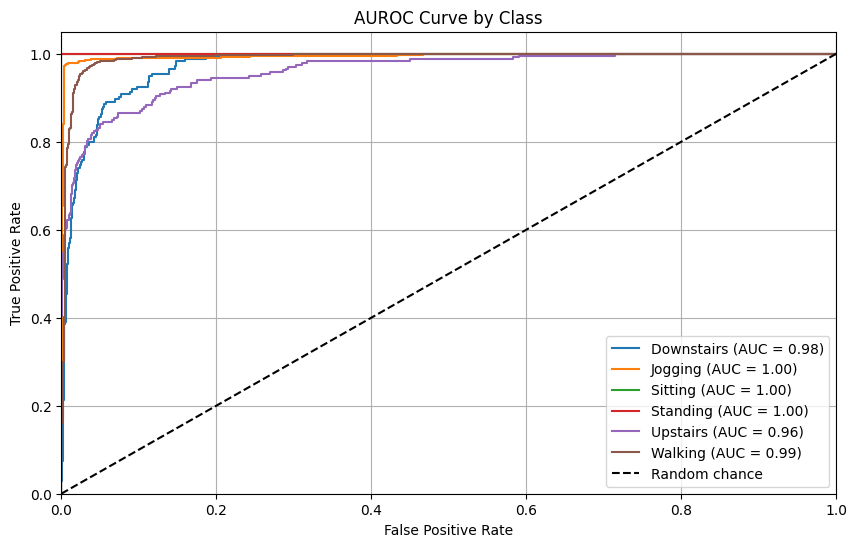

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the output
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = default_gbm.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve by Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

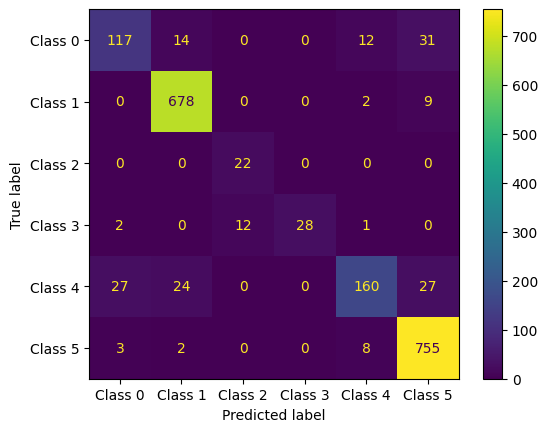

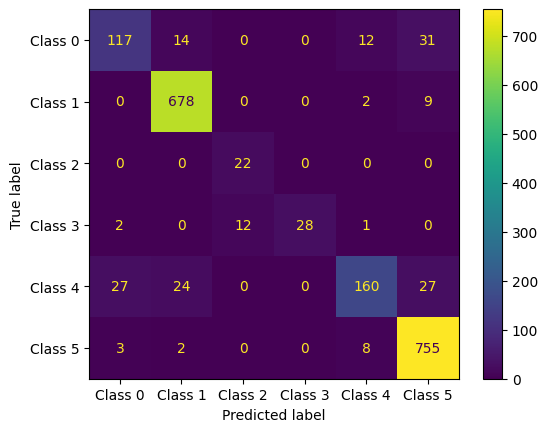

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

activity_labels = {i: str(label) for i, label in enumerate(default_gbm.classes_)}

# Assuming `default_gbm` is the best model and `X_test` and `y_test` are already defined
ConfusionMatrixDisplay.from_estimator(default_gbm, X_test, y_test, display_labels=list(activity_labels.values())).plot()

In [23]:
print(classification_report(y_test, y_pred, target_names=list(activity_labels.values())))

In [ ]:
import os
kaggle_predictions = default_gbm.predict(X_kaggle)

# Create CSV (you'll need user_snippet column from the pre-processed data)
user_snippet_kaggle = pd.read_csv('data-preprocess/new/user_snippet_kaggle.csv')
submission = pd.DataFrame({
    'user_snippet': user_snippet_kaggle['user_snippet'],
    'prediction': kaggle_predictions
})

os.makedirs('predictions', exist_ok=True)

# Save with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'predictions/gbm_predictions_{timestamp}'
submission.to_csv(f'{filename}.csv', index=False)

print(f"Saved GBM predictions.")